<a href="https://colab.research.google.com/github/sudeeraattanayake/Machine-Learning/blob/main/Real_World_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import dataset

In [2]:
df_train = pd.read_csv('train.csv')

In [3]:
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
df_train.shape

(550068, 12)

In [5]:
df_test = pd.read_csv('test.csv')

In [6]:
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [7]:
df_test.shape

(233599, 11)

#Merge

In [10]:
df = pd.concat([df_train, df_test], ignore_index=True)

In [12]:
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [13]:
df.tail(4)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
783663,1006036,P00254642,F,26-35,15,B,4+,1,5,8.0,NaN,NaN
783664,1006036,P00031842,F,26-35,15,B,4+,1,1,5.0,12.0,NaN
783665,1006037,P00124742,F,46-50,1,C,4+,0,10,16.0,NaN,NaN
783666,1006039,P00316642,F,46-50,0,B,4+,1,4,5.0,NaN,NaN


In [14]:
df.shape

(783667, 12)

In [15]:
df.to_csv('combined_data.csv', index=False)

#EDA

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [18]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [19]:
df.describe().round()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,783667.0,783667.0,783667.0,783667.0,537685.0,237858.0,550068.0
mean,1003029.0,8.0,0.0,5.0,10.0,13.0,9264.0
std,1727.0,7.0,0.0,4.0,5.0,4.0,5023.0
min,1000001.0,0.0,0.0,1.0,2.0,3.0,12.0
25%,1001519.0,2.0,0.0,1.0,5.0,9.0,5823.0
50%,1003075.0,7.0,0.0,5.0,9.0,14.0,8047.0
75%,1004478.0,14.0,1.0,8.0,15.0,16.0,12054.0
max,1006040.0,20.0,1.0,20.0,18.0,18.0,23961.0


In [20]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [21]:
df.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0


In [24]:
df.drop('User_ID', axis=1, inplace=True)

In [25]:
df.head(3)

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0


In [27]:
df.isnull().sum()

,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,245982
Product_Category_3,545809


#Distribution of F

/tmp/ipykernel_811/3028130985.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette='viridis')


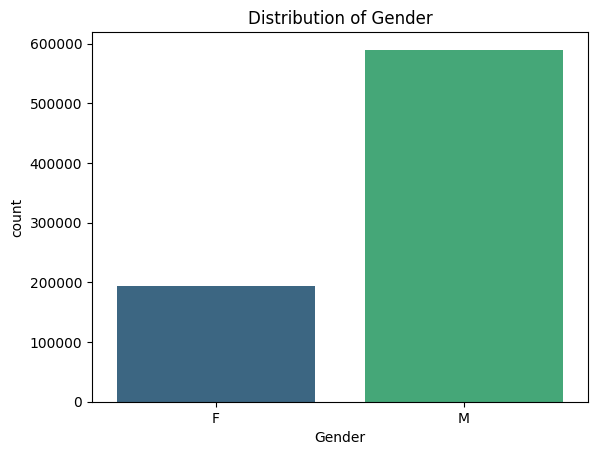

In [30]:
sns.countplot(x="Gender", data=df, palette='viridis')
plt.title("Distribution of Gender")
plt.show()

/tmp/ipykernel_811/1874464557.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Marital_Status", data=df, palette='viridis')


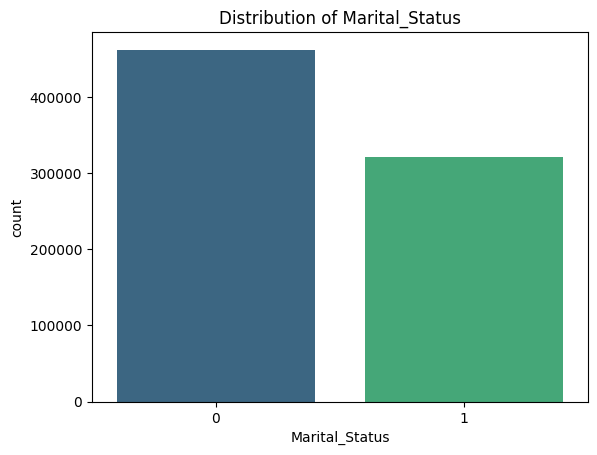

In [31]:
sns.countplot(x="Marital_Status", data=df, palette='viridis')
plt.title("Distribution of Marital_Status")
plt.show()

/tmp/ipykernel_811/3664667630.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Age", data=df, palette='viridis')


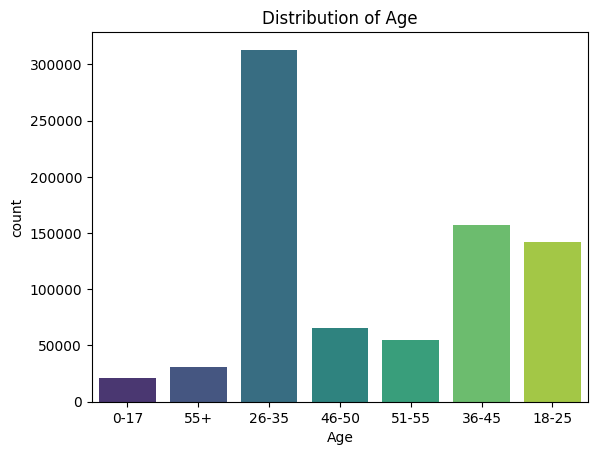

In [33]:
sns.countplot(x="Age", data=df, palette='viridis')
plt.title("Distribution of Age")
plt.show()

/tmp/ipykernel_811/1615037512.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Occupation", data=df, palette='viridis')


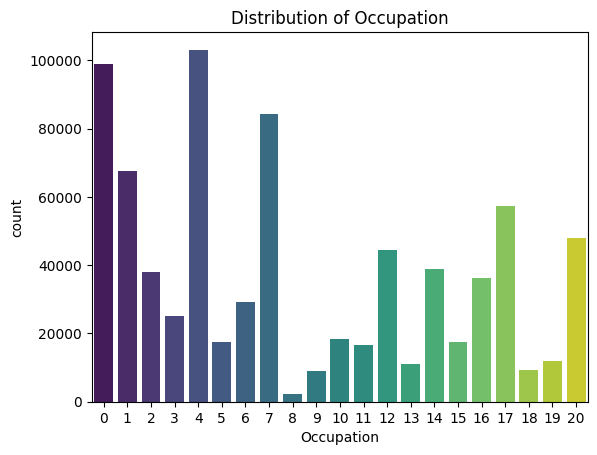

In [34]:
sns.countplot(x="Occupation", data=df, palette='viridis')
plt.title("Distribution of Occupation")
plt.show()

#Data Preprocessing

In [38]:
pd.get_dummies(df['Gender'], dtype=int, drop_first=1)

,M
0,0
1,0
2,0
3,0
4,1
...,...
783662,0
783663,0
783664,0
783665,0


In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [41]:
df.head(5)

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [58]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['Age'] = oe.fit_transform(df[['Age']])

In [55]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df[['City_Category']])
cols = encoder.get_feature_names_out(['City_Category'])
df = df.drop('City_Category', axis=1)
df[cols] = encoded_data


In [56]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [57]:
df['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

#Make Sen -> Con
#Make No Sen -> Dis

In [84]:
df['Product_Category_2'].value_counts()

,count
Product_Category_2,
8.0,337299
14.0,78834
2.0,70498
16.0,61687
15.0,54114
5.0,37165
4.0,36705
6.0,23575
11.0,20230


In [80]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(8.0)

In [81]:
df.isnull().sum()

,0
Product_ID,0
Gender,0
Age,0
Occupation,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0
Product_Category_3,0
Purchase,233599


In [85]:
df['Product_Category_3'].value_counts()

,count
Product_Category_3,
8.0,337299
14.0,78834
2.0,70498
16.0,61687
15.0,54114
5.0,37165
4.0,36705
6.0,23575
11.0,20230


In [86]:
df['Product_Category_3'] = df['Product_Category_3'].fillna(16)

In [87]:
df.isnull().sum()

,0
Product_ID,0
Gender,0
Age,0
Occupation,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0
Product_Category_3,0
Purchase,233599


In [78]:
df.head(5)

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00069042,0,0.0,10,2,0,3,8.0,8.0,8370.0,0.0,0.0
1,P00248942,0,0.0,10,2,0,1,6.0,6.0,15200.0,0.0,0.0
2,P00087842,0,0.0,10,2,0,12,8.0,8.0,1422.0,0.0,0.0
3,P00085442,0,0.0,10,2,0,12,14.0,14.0,1057.0,0.0,0.0
4,P00285442,1,6.0,16,4+,0,8,8.0,8.0,7969.0,0.0,1.0


In [88]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [89]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '')

In [90]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4', '3', '1', '0'], dtype=object)

In [92]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  float64
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int64  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  City_Category_B             783667 non-null  float64
 11  City_Category_C             783667 non-null  float64
dtypes: float64(6), int64(5), object(1)
memory usage: 71.7+ MB


#visulaizing some plot

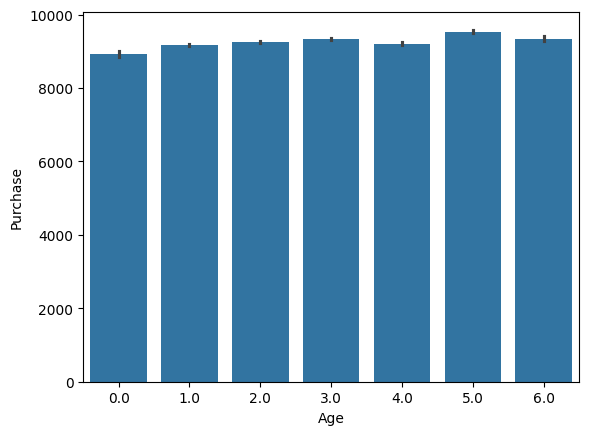

In [94]:
sns.barplot(x='Age', y='Purchase', data=df)
plt.show()

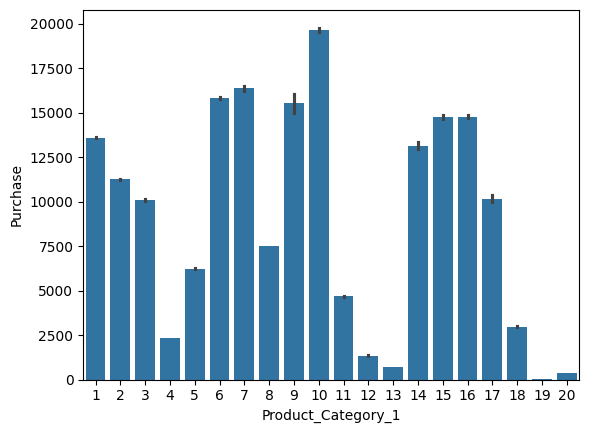

In [95]:
sns.barplot(x='Product_Category_1', y='Purchase', data=df)
plt.show()

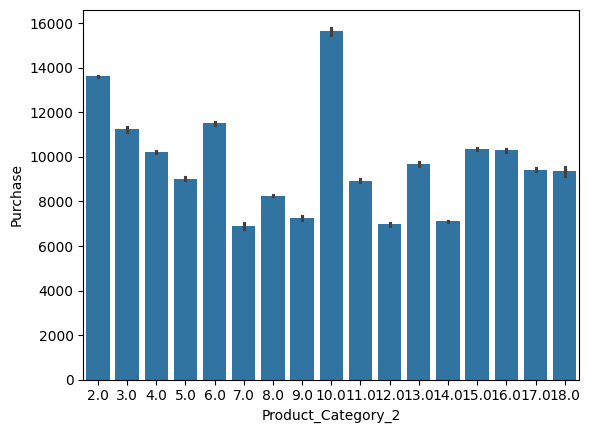

In [96]:
sns.barplot(x='Product_Category_2', y='Purchase', data=df)
plt.show()

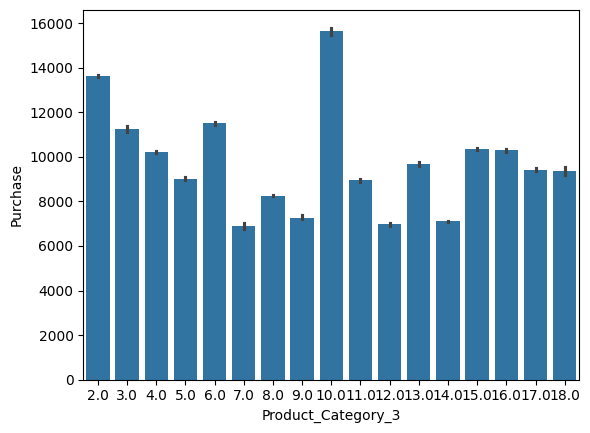

In [97]:
sns.barplot(x='Product_Category_3', y='Purchase', data=df)
plt.show()

#Train

In [100]:
df_train_processed = df[~df['Purchase'].isnull()]

In [99]:
df_test_processed = df[df['Purchase'].isnull()]

In [102]:
df_train_processed.shape

(550068, 12)

In [103]:
df_test_processed.shape

(233599, 12)

In [107]:
X = df_train_processed.drop(['Product_ID', 'Purchase'], axis=1)
y = df_train_processed['Purchase']

In [108]:
X

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,City_Category_B,City_Category_C
0,0,0.0,10,2,0,3,8.0,8.0,0.0,0.0
1,0,0.0,10,2,0,1,6.0,6.0,0.0,0.0
2,0,0.0,10,2,0,12,8.0,8.0,0.0,0.0
3,0,0.0,10,2,0,12,14.0,14.0,0.0,0.0
4,1,6.0,16,4,0,8,8.0,8.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
550063,1,5.0,13,1,1,20,8.0,8.0,1.0,0.0
550064,0,2.0,1,3,0,20,8.0,8.0,0.0,1.0
550065,0,2.0,15,4,1,20,8.0,8.0,1.0,0.0
550066,0,6.0,1,2,0,20,8.0,8.0,0.0,1.0


In [109]:
y

,Purchase
0,8370.0
1,15200.0
2,1422.0
3,1057.0
4,7969.0
...,...
550063,368.0
550064,371.0
550065,137.0
550066,365.0


In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [113]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'Occupation', 'Stay_In_Current_City_Years', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train[numerical_cols])
X_test_scaled = sc.transform(X_test[numerical_cols])

In [114]:
X_train.head(3)

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,City_Category_B,City_Category_C
500304,1,2.0,16,0,0,8,14.0,14.0,0.0,0.0
16861,1,2.0,1,2,1,16,8.0,8.0,1.0,0.0
113230,1,1.0,7,1,0,8,16.0,16.0,0.0,0.0


#Train ML Models

In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#ML model 1

In [120]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 22209720.69027825


#Ml model 2

In [121]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=1)
rf_reg.fit(X_train_scaled, y_train)
y_pred = rf_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 8971969.682765998


#Save the model

In [126]:
import joblib
joblib.dump(rf_reg, 'rf_model.joblib')

['rf_model.joblib']

### Comparison of Model Performance

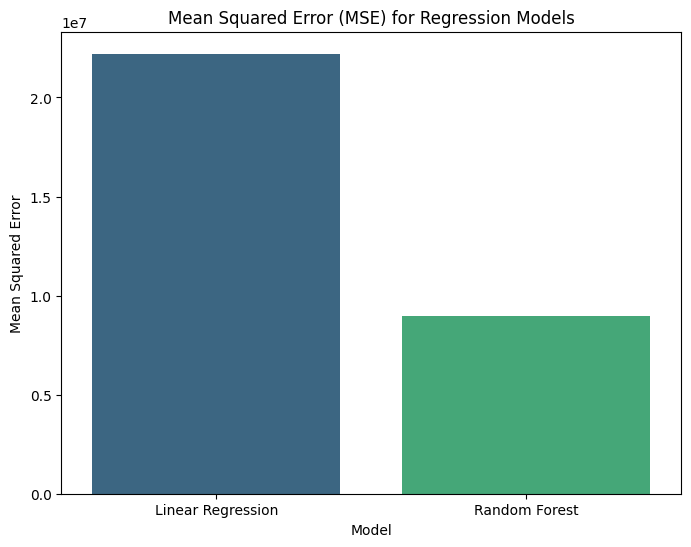

In [123]:
models = ['Linear Regression', 'Random Forest']
mse_values = [22209720.69027825, 8971969.682765998]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=mse_values, hue=models, palette='viridis', legend=False)
plt.title('Mean Squared Error (MSE) for Regression Models')
plt.ylabel('Mean Squared Error')
plt.xlabel('Model')
plt.show()